In [1]:
import pandas as pd
import numpy as np

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
clients = pd.read_csv(r"C:\Users\rasha\OneDrive\Desktop\UnicornDenmart\Cleaned_files\Clients.csv", encoding = 'Latin')
orders = pd.read_csv(r"C:\Users\rasha\OneDrive\Desktop\UnicornDenmart\Cleaned_files\Orders_cleaned.csv", encoding = 'Latin')
products = pd.read_csv(r"C:\Users\rasha\OneDrive\Desktop\UnicornDenmart\Cleaned_files\Products_cleaned.csv", encoding = 'Latin')

# Analysing 'Clients' dataframe

In [9]:
clients.shape

(495, 5)

In [10]:
clients.info()

<class 'pandas.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Clinic_id             495 non-null    str  
 1   City                  495 non-null    str  
 2   Clinic_size           495 non-null    str  
 3   Avg_patients_per_day  495 non-null    int64
 4   State                 495 non-null    str  
dtypes: int64(1), str(4)
memory usage: 19.5 KB


In [15]:
# Unique value counts for each column
print("Number of unique values in : ")
for i in clients.columns:
    print(i,"-" , clients[i].nunique())

Number of unique values in : 
Clinic_id - 495
City - 207
Clinic_size - 3
Avg_patients_per_day - 166
State - 25


In [ ]:
# clinic_ids does not have any duplicate values, number of rows in dataframe match unique values count

# check null values in Clients

In [16]:
clients.isnull().sum()

Clinic_id               0
City                    0
Clinic_size             0
Avg_patients_per_day    0
State                   0
dtype: int64

In [ ]:
# No Nulls detected

# Clinics Distribution Analysis

In [29]:
# Count clinics by state
clients.groupby('State')['Clinic_id'].count().sort_values(ascending = False)

State
Tamilnadu          84
Maharashtra        77
Kerala             74
Delhi              37
Uttar Pradesh      33
Gujarat            30
Andhra Pradesh     27
Punjab             23
Rajasthan          14
Telangana          13
Karnataka          12
Madhya Pradesh     12
Jharkhand          10
Haryana            10
Chhatisgarh         7
Chandigarh          7
Goa                 5
Odisha              5
West Bengal         4
Uttrakhand          3
Assam               3
Bihar               2
Overseas            1
Jammu & Kashmir     1
YSTATE              1
Name: Clinic_id, dtype: int64

In [27]:
# Count clinics by City
clients.groupby('City')['Clinic_id'].count().sort_values(ascending = False)

City
Hyderabad     20
Chennai       15
Pune          13
Coimbatore    13
Malappuram    11
              ..
Khammam        1
Khar Road      1
Kharghar       1
Kollam         1
Zirakpur       1
Name: Clinic_id, Length: 207, dtype: int64

In [23]:
# Count by clinic_size
clients.groupby('Clinic_size')['Clinic_id'].count().sort_values(ascending = False)

Clinic_size
Small     183
Medium    158
Large     154
Name: Clinic_id, dtype: int64

# Geographic Concentration

In [31]:
# Top cities with most clinics
clients.groupby('City')['Clinic_id'].count().sort_values(ascending = False).head(10)

City
Hyderabad     20
Chennai       15
Pune          13
Coimbatore    13
Malappuram    11
Rajkot        10
Gurugram      10
Trivandrum     9
Thane          9
Salem          9
Name: Clinic_id, dtype: int64

In [30]:
# Top States with most Clinics
clients.groupby('State')['Clinic_id'].count().sort_values(ascending = False).head(10)

State
Tamilnadu         84
Maharashtra       77
Kerala            74
Delhi             37
Uttar Pradesh     33
Gujarat           30
Andhra Pradesh    27
Punjab            23
Rajasthan         14
Telangana         13
Name: Clinic_id, dtype: int64

In [ ]:
# TamilNadu, Maharashtra, Kerala contribute highest clinic concentration
# These states can be targets for SALES EXPANSION

# Patient Load Analysis

<Axes: xlabel='Avg_patients_per_day', ylabel='Count'>

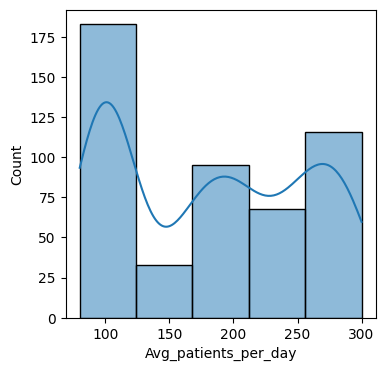

In [35]:
# Distribution of avg_patients_per_day
plt.figure(figsize = (4,4))
sns.histplot(clients['Avg_patients_per_day'], kde = True, bins = 5)

In [ ]:
#>???????????????????????? weired distributon

In [36]:
# Bucket Avg_patients_per_day into low, Medium, High
def Avg_patients_per_day_bucket(x):
    if x > 200:
        return "High"
    elif x >= 100 and x < 200:
        return "Medium"
    else:
        return "Low"

clients['patient_bucket'] = clients['Avg_patients_per_day'].apply(Avg_patients_per_day_bucket)

In [38]:
clients_sorted = clients.sort_values(by = 'Avg_patients_per_day', ascending = False)

top_n = int(0.25 * len(clients_sorted))
top_clinics = clients_sorted.head(top_n)

top_patients = top_clinics['Avg_patients_per_day'].sum()
total_patients = clients_sorted['Avg_patients_per_day'].sum()

percentage = round((top_patients/ total_patients)*100,2)
print(f"Top 25% clinics handle {percentage}% patient load")

Top 25% clinics handle 37.84% patient load


In [41]:
# These are High Value clients that can be further targeted 
list(top_clinics['Clinic_id'])

['Cl_268',
 'Cl_79',
 'Cl_373',
 'Cl_396',
 'Cl_319',
 'Cl_14',
 'Cl_4',
 'Cl_466',
 'Cl_269',
 'Cl_51',
 'Cl_360',
 'Cl_275',
 'Cl_424',
 'Cl_313',
 'Cl_63',
 'Cl_197',
 'Cl_312',
 'Cl_167',
 'Cl_305',
 'Cl_45',
 'Cl_101',
 'Cl_208',
 'Cl_419',
 'Cl_279',
 'Cl_142',
 'Cl_363',
 'Cl_224',
 'Cl_229',
 'Cl_39',
 'Cl_479',
 'Cl_178',
 'Cl_127',
 'Cl_307',
 'Cl_189',
 'Cl_158',
 'Cl_320',
 'Cl_256',
 'Cl_357',
 'Cl_448',
 'Cl_491',
 'Cl_310',
 'Cl_28',
 'Cl_254',
 'Cl_177',
 'Cl_296',
 'Cl_248',
 'Cl_61',
 'Cl_109',
 'Cl_8',
 'Cl_468',
 'Cl_182',
 'Cl_35',
 'Cl_137',
 'Cl_49',
 'Cl_1',
 'Cl_100',
 'Cl_73',
 'Cl_24',
 'Cl_140',
 'Cl_289',
 'Cl_103',
 'Cl_134',
 'Cl_331',
 'Cl_330',
 'Cl_351',
 'Cl_203',
 'Cl_236',
 'Cl_352',
 'Cl_162',
 'Cl_452',
 'Cl_83',
 'Cl_175',
 'Cl_267',
 'Cl_215',
 'Cl_89',
 'Cl_336',
 'Cl_374',
 'Cl_403',
 'Cl_147',
 'Cl_40',
 'Cl_71',
 'Cl_442',
 'Cl_338',
 'Cl_133',
 'Cl_111',
 'Cl_369',
 'Cl_46',
 'Cl_425',
 'Cl_75',
 'Cl_345',
 'Cl_456',
 'Cl_113',
 'Cl_91',
 '

In [43]:
# Clinic Size vs Patient Load
clients.groupby('Clinic_size')['Avg_patients_per_day'].mean()

Clinic_size
Large     271.077922
Medium    190.164557
Small     100.530055
Name: Avg_patients_per_day, dtype: float64

In [ ]:
# Large clinics handle more avg_number_of_patients, is almost 3X of small clinics, 
# These clinics can be priority for premium products

# As number of patients are more , such clinics can also be targeted for more frequent sales of consumables

# Distribution of clinic sizes per state

In [54]:
clients_grouped = clients.groupby(['patient_bucket', 'Clinic_size'])['Clinic_id'].count().reset_index()
clients_grouped.columns = ['patient_bucket', 'Clinic_size', 'clinic_count']

In [55]:
pivot_df = clients_grouped.pivot(index = 'patient_bucket', columns = 'Clinic_size', values = 'clinic_count')

<Axes: xlabel='patient_bucket'>

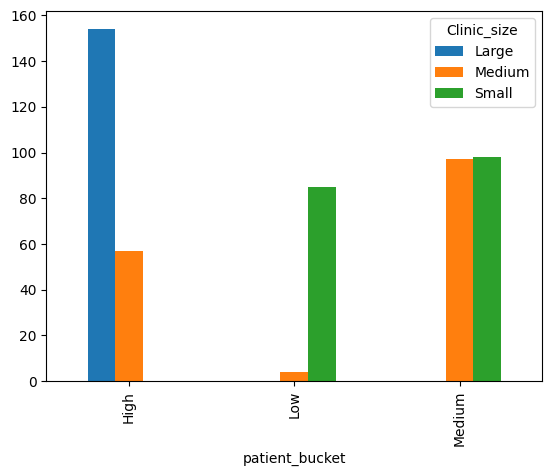

In [56]:
pivot_df.plot(kind = 'bar')

In [57]:
# High patient-load segments are dominated by larger clinics, which are key targets for supply optimization

# Analysing 'Products' dataframe

In [4]:
products.shape

(208, 7)

In [5]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   product_id     208 non-null    str  
 1   product_name   208 non-null    str  
 2   category_id    208 non-null    str  
 3   category       208 non-null    str  
 4   cost_price     208 non-null    int64
 5   selling_price  208 non-null    int64
 6   shelf_life     208 non-null    int64
dtypes: int64(3), str(4)
memory usage: 11.5 KB


In [6]:
# Check nulls
products.isnull().sum()

product_id       0
product_name     0
category_id      0
category         0
cost_price       0
selling_price    0
shelf_life       0
dtype: int64

In [7]:
products.describe()

,cost_price,selling_price,shelf_life
count,2.080000e+02,2.080000e+02,208.000000
mean,3.056001e+05,5.177185e+05,6.288462
std,4.969110e+05,8.403748e+05,1.794641
min,3.000000e+02,8.000000e+02,2.000000
25%,2.582700e+04,4.520500e+04,5.000000
50%,8.009900e+04,1.200000e+05,7.000000
75%,3.338292e+05,5.459762e+05,8.000000
max,2.200000e+06,3.510000e+06,9.000000


In [8]:
# Check Outliers in cost_price and Selling_price

cp_q1  = np.percentile(products['cost_price'],25)
cp_q3 = np.percentile(products['cost_price'],75)

In [9]:
cp_IQR = cp_q3-cp_q1
upper_cp = cp_q3 + (1.5* cp_IQR)
lower_cp = cp_q1 - (1.5* cp_IQR)

In [10]:
mask_cp = (products['cost_price'] > upper_cp) | (products['cost_price'] < lower_cp) 

In [11]:
products['cost_price_flagged'] = np.where(mask_cp, 'Outlier', 'Normal')

In [12]:
# Outliers for Selling_price

In [19]:
sp_q1  = np.percentile(products['selling_price'],25)
sp_q3 = np.percentile(products['selling_price'],75)

In [20]:
sp_IQR = sp_q3-sp_q1
upper_sp = sp_q3 + (1.5* sp_IQR)
lower_sp = sp_q1 - (1.5* sp_IQR)

In [21]:
mask = (products['selling_price'] > upper_sp) | (products['selling_price'] < lower_sp) 

In [22]:
products['selling_price_flagged'] = np.where(mask, 'Outlier', 'Normal')

In [24]:
products['selling_price_flagged'].value_counts()

selling_price_flagged
Normal     188
Outlier     20
Name: count, dtype: int64

<Axes: xlabel='cost_price', ylabel='Count'>

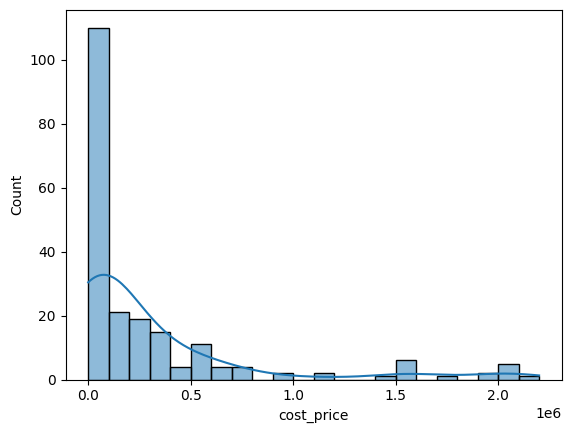

In [26]:
# Check distribution of cost_price
sns.histplot(products['cost_price'], kde= True)

<Axes: xlabel='selling_price', ylabel='Count'>

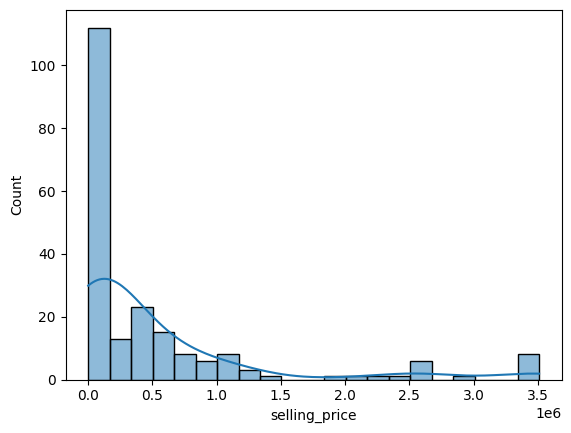

In [27]:
# Check distribution of cost_price
sns.histplot(products['selling_price'], kde= True)

In [30]:
# Both cost__price and selling_price are highly right skewed
print(f"cost_price skew: {products['cost_price'].skew()}")
print(f"cost_price skew: {products['selling_price'].skew()}")

cost_price skew: 2.3999884515362506
cost_price skew: 2.3754496380466272


In [ ]:
# High prices may be valid premium products
# Not actual “errors”

<Axes: ylabel='cost_price'>

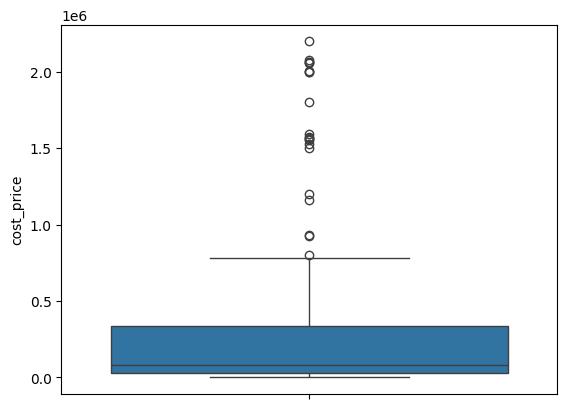

In [32]:
# Box plots for cost_price and selling_price
sns.boxplot(products['cost_price'])


<Axes: ylabel='cost_price'>

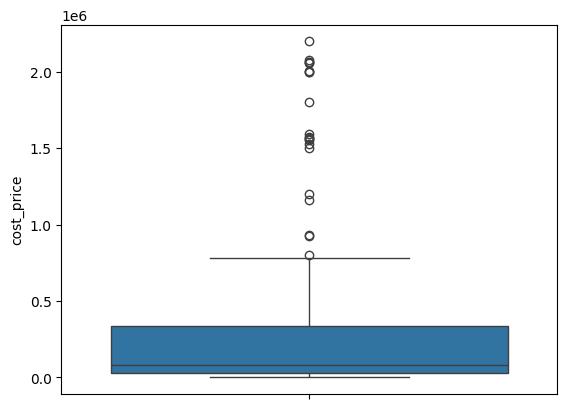

In [34]:
sns.boxplot(products['cost_price'])

In [ ]:
# Box Plot further confirms skewness and lots of prices at higher ranges (premium products)

In [36]:
products.columns

Index(['product_id', 'product_name', 'category_id', 'category', 'cost_price',
       'selling_price', 'shelf_life', 'cost_price_flagged',
       'selling_price_flagged'],
      dtype='str')

<Axes: xlabel='shelf_life', ylabel='Count'>

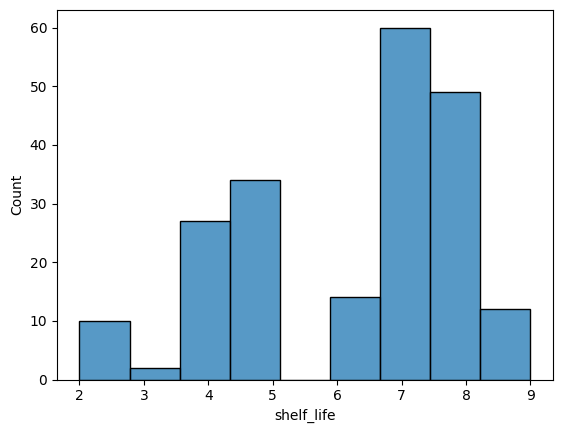

In [38]:
# Check shelf_life distribution
sns.histplot(products['shelf_life'])

In [40]:
# Avg_Shelf_life vs category

products.groupby('category')['shelf_life'].mean().sort_values(ascending = False)

category
Dental Milling Machine                    9.000000
Dental_Chair                              8.000000
Physiodispensor and Piezosurgery Units    8.000000
Physiodispensor Unit                      8.000000
Light Cure Unit                           8.000000
Implant Uni-verse                         8.000000
Imaging                                   7.181818
Dental HandPeice                          7.023810
Dental Autoclaves                         7.000000
Dental Lasers                             7.000000
Dental Micromotor                         7.000000
Dental Sintering Furnace                  7.000000
Dental Stimulator                         7.000000
Dental 3D printer                         6.000000
Dental Handpiece Lubrication Machine      6.000000
Intraoral Scanner                         5.642857
Dental Lab Scanner                        5.333333
Digital Magnification                     5.000000
Endomotors                                5.000000
Face Scanner          

In [ ]:
# Premium high end products such as dental_chairs, milling machines have more shelf_life unlike consumables
# Inventory for different item categories should be maintained accordingly to prevent dead_stock or stockout situations

# Analysing 'Orders' dataframe

In [41]:
orders.shape

(4987, 11)

In [42]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 4987 entries, 0 to 4986
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          4987 non-null   str    
 1   clinic_id         4987 non-null   str    
 2   product_id        4987 non-null   str    
 3   product_name      4987 non-null   str    
 4   category          4987 non-null   str    
 5   order_date        4982 non-null   str    
 6   quantity          4987 non-null   int64  
 7   delivered_to      4987 non-null   str    
 8   delivery_time     4987 non-null   int64  
 9   current_stock     4983 non-null   float64
 10  order_date_clean  4982 non-null   str    
dtypes: float64(1), int64(2), str(8)
memory usage: 428.7 KB


In [44]:
orders.isnull().sum()

order_id            0
clinic_id           0
product_id          0
product_name        0
category            0
order_date          5
quantity            0
delivered_to        0
delivery_time       0
current_stock       4
order_date_clean    5
dtype: int64

In [46]:
# as there are just 5 nulls in order_date_clean , dropping  5 rows
orders = orders.dropna(subset = ['order_date_clean'])

In [47]:
# Fill current_stock nulls with median
orders['current_stock'] = orders['current_stock'].fillna(orders['current_stock'].median())

In [49]:
orders.columns

Index(['order_id', 'clinic_id', 'product_id', 'product_name', 'category',
       'order_date', 'quantity', 'delivered_to', 'delivery_time',
       'current_stock', 'order_date_clean'],
      dtype='str')

In [54]:
orders['order_date_clean'] = pd.to_datetime(orders['order_date_clean'])

# Product demand over time

In [56]:
orders.groupby(['product_id', pd.Grouper(key = 'order_date_clean', freq = 'ME')])['quantity'].sum()

product_id  order_date_clean
P1          2020-01-31           9
            2020-12-31          12
            2021-03-31           7
            2021-06-30           3
            2021-07-31          11
                                ..
P99         2025-04-30           4
            2025-05-31          11
            2025-09-30           6
            2025-11-30           8
            2025-12-31           9
Name: quantity, Length: 4239, dtype: int64

In [ ]:
# Demands seems to be irregualar, Inventory needs better planning, Should not keep constant stock, 
# Pattern can also mean seasonality where December indicates year end demands

# Stock Risk Detection

In [57]:
orders['stock_risk'] = orders['current_stock'] / orders.groupby('product_id')['quantity'].transform('mean')

In [61]:
orders[['product_id', 'stock_risk']].sort_values(by = ['stock_risk'], ascending = False).head(20)

,product_id,stock_risk
584,P165,110.574713
4964,P172,106.742857
4347,P165,105.287356
684,P168,98.634921
527,P164,95.979381
118,P171,93.990385
4852,P172,93.942857
1010,P171,93.326923
2883,P171,92.884615
4471,P172,92.114286


In [ ]:
# Above result indicate top 20 products that are at high risk  of stockout, This analysis
# can help in inventory planning

In [65]:
# Delivery Efficiency Analysis
orders.groupby('delivered_to')['delivery_time'].mean().sort_values(ascending = False).head(10)

delivered_to
Goregaon           7.461538
Rourkela           7.437500
Mallapuram         7.346939
Muzzaffar Nagar    7.340000
Pathanamthitta     7.333333
Guwahati           7.282609
Jalgaon            7.260000
Kolhapur           7.250000
Varanasi           7.198020
Jalna              7.192982
Name: delivery_time, dtype: float64

In [ ]:
# Places that are far from warehouses usually will have higher mean delivery time, though
# one exception in above result is 'Muzzaffar Nagar', which can be further investigated
# Mean delivery time for 'Muzzaffar Nagar' should not be thigh high ideally, it might indicate a problematic
# 'carrier service' for this particular destination which can turn into Logistics optimization opportunity

# Clinic-Level Consumption Behavior

In [67]:
orders.groupby('clinic_id')['quantity'].sum().sort_values(ascending = False).head(20)

clinic_id
Cl_62    413
Cl_74    410
Cl_63    363
Cl_24    349
Cl_92    347
Cl_4     345
Cl_1     345
Cl_93    345
Cl_79    344
Cl_89    342
Cl_16    339
Cl_13    338
Cl_57    337
Cl_98    331
Cl_72    330
Cl_17    328
Cl_27    323
Cl_52    322
Cl_48    321
Cl_94    321
Name: quantity, dtype: int64

In [ ]:
# These indicate High-value clinics, can be targetted for upselling / priority service

# Dead Stock Detection

In [73]:
stock = orders.groupby('product_id')['order_date_clean'].max().reset_index(name = 'last purchased date')
dead_stock = stock[stock['last purchased date'] < '2025-07-01']
dead_stock
# products that are not sold in last 6 months might need  a closer look for better inventory management

,product_id,last purchased date
19,P116,2025-05-27
20,P117,2025-05-31
29,P125,2025-06-03
38,P133,2025-05-22
54,P148,2025-03-24
65,P158,2025-06-19
75,P167,2025-02-01
95,P185,2025-05-14
134,P22,2025-04-30
139,P25,2025-05-17


# Fast vs Slow Moving Product Classification

In [77]:
orders['total_qty'] = orders.groupby('product_id')['quantity'].transform('sum')
# quantities above 150 are considered as fast moving, else they are slow moving
orders['classification'] = orders['total_qty'].apply(lambda x : "Fast_Moving" if x > 150  else "Slow_Moving")

# Order Frequency per Clinic

In [79]:
orders.groupby('clinic_id')['order_id'].nunique().sort_values(ascending = False).head(10)

clinic_id
Cl_74    70
Cl_62    70
Cl_24    66
Cl_98    64
Cl_36    63
Cl_1     62
Cl_92    61
Cl_54    61
Cl_13    61
Cl_16    61
Name: order_id, dtype: int64

By analyzing clinic-wise order patterns, we can segment high-value clinics and 
optimize inventory allocation by maintaining safety stock for them. 
This ensures demand fulfillment during peak periods and minimizes the risk of lost sales.

# Lead Time Impact on Demand

In [80]:
orders.groupby('delivery_time')['quantity'].mean()

delivery_time
2     5.442623
3     5.058824
4     5.623698
5     5.495413
6     5.435866
7     5.662500
8     5.728353
9     5.466087
10    5.442238
Name: quantity, dtype: float64

In [ ]:
# Slow delivery is not affecting demand significantly, 
# slow delivery might just be a result of delivery to far off places form the warehouse

# Category Performance

In [100]:
orders_products = orders.merge(products, on = 'product_id', how = 'outer')

In [89]:
orders_products.columns

Index(['order_id', 'clinic_id', 'product_id', 'product_name_x', 'category_x',
       'order_date', 'quantity', 'delivered_to', 'delivery_time',
       'current_stock', 'order_date_clean', 'stock_risk', 'total_qty',
       'classification', 'product_name_y', 'category_id', 'category_y',
       'cost_price', 'selling_price', 'shelf_life', 'cost_price_flagged',
       'selling_price_flagged'],
      dtype='str')

In [101]:
orders_products['revenue'] = orders_products['quantity']* orders_products['selling_price']

In [111]:
high_value_product_categories = orders_products.groupby('category_id')['revenue'].sum().sort_values(ascending = False).reset_index()
high_value_product_categories

,category_id,revenue
0,C_14,4.417420e+09
1,C_5,2.196150e+09
2,C_11,1.354635e+09
3,C_20,8.804839e+08
4,C_13,7.478497e+08
5,C_1,6.667000e+08
6,C_18,6.527258e+08
7,C_21,5.832942e+08
8,C_9,5.678773e+08
9,C_12,4.433526e+08


# Inventory Turnover Proxy

In [103]:
turnover = orders_products.groupby('product_id')['quantity'].sum() / orders_products.groupby('product_id')['current_stock'].mean()

In [104]:
turnover.sort_values(ascending = False)

product_id
P128    268.923077
P126    236.764706
P136    169.000000
P132    168.000000
P130    147.115385
           ...    
P164      0.370676
P166      0.361012
P165      0.338192
P168      0.298143
P172      0.262295
Length: 221, dtype: float64

In [ ]:
# Products with higher turnover are more effciently managed, lower values indicate overstock

In [107]:
# Repeat Order Behaviour
orders_products.groupby(['clinic_id', 'category_id'])['order_id'].count().sort_values(ascending = False)

clinic_id  category_id
Cl_74      C_8            18
Cl_33      C_8            17
Cl_39      C_8            16
Cl_58      C_8            16
Cl_60      C_8            15
                          ..
Cl_46      C_3             1
Cl_71      C_7             1
Cl_46      C_26            1
           C_23            1
Cl_28      C_1             1
Name: order_id, Length: 1736, dtype: int64

In [ ]:
# It helps in analysing categories that are sold repeatedly and which categories are more commonly bought by a particular clinic
# This analysis can help in better and personalised marketing approach

In [112]:
high_value_product_categories.to_csv("high_value_product_categories.csv", index=False)

In [110]:
orders_products.to_csv("orders_products.csv", index=False)